In [ ]:
""""
Load integrated single-cell breast cancer atlas in backed mode for memory efficiency.
Subset data to a single donor for feasibility testing of CCC pipeline.
Standardize gene names and ensure uniqueness for downstream compatibility.
Normalize and log-transform expression matrix.
Aggregate expression at cell-type level.
Load curated ligand–receptor interaction database (consensus set).
Compute ligand–receptor communication scores using aggregated expression.
Generate ranked cell–cell communication interaction table.
Output used for downstream feature engineering and ML modeling
"""

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import scanpy as sc

adata = sc.read_h5ad(
    r"C:\BRCA\BRCA Project\data\IntegratedAtlas.h5ad",
    backed="r"
)
adata

AnnData object with n_obs × n_vars = 621200 × 37389 backed at 'C:\\BRCA\\BRCA Project\\data\\IntegratedAtlas.h5ad'
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

In [2]:
donor = adata.obs["donor_id"].unique()[0]
adata_p = adata[adata.obs["donor_id"] == donor].to_memory()

adata_p

AnnData object with n_obs × n_vars = 6176 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

In [3]:
adata_p.var_names = adata_p.var["feature_name"]
adata_p.var_names_make_unique()

In [4]:
sc.pp.normalize_total(adata_p, target_sum=1e4)
sc.pp.log1p(adata_p)

In [5]:
expr = adata_p.to_df()
expr["cell_type"] = adata_p.obs["cell_type"].values

mean_expr = expr.groupby("cell_type").mean()

mean_expr.shape

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33412\1100472295.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expr.groupby("cell_type").mean()


(24, 37389)

In [6]:
import liana.resource as lr

lr_db = lr.select_resource("consensus")
lr_db.head()

,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [8]:
import pandas as pd

scores = []

for _, row in lr_db.iterrows():
    lig = row["ligand"]
    rec = row["receptor"]

    if lig in mean_expr.columns and rec in mean_expr.columns:
        score = (mean_expr[lig].values * mean_expr[rec].values).sum()
        scores.append([lig, rec, float(score)])

ccc_df = pd.DataFrame(scores, columns=["ligand", "receptor", "score"])
ccc_df.sort_values("score", ascending=False).head(10)

,ligand,receptor,score
2774,VIM,CD44,58.513569
78,HLA-B,CD3D,50.588818
3033,HMGB1,CXCR4,45.188866
119,APP,CD74,35.022282
1433,LGALS1,PTPRC,26.619255
2515,TIMP1,CD63,26.476229
1432,LGALS1,ITGB1,25.974648
1624,MIF,TNFRSF14,24.714783
77,HLA-B,CD8A,23.816559
170,HLA-C,CD8A,22.594717


In [9]:
ccc_df.shape

(3489, 3)

In [10]:
ccc_df.head(10)

,ligand,receptor,score
0,LGALS9,PTPRC,8.633867
1,LGALS9,MET,1.044805
2,LGALS9,CD44,8.393451
3,LGALS9,LRP1,0.776248
4,LGALS9,CD47,3.758318
5,LGALS9,PTPRK,1.168318
6,LGALS9,COLEC12,0.296762
7,LGALS9,HAVCR2,3.943516
8,LGALS9,MRC2,0.637201
9,DLL1,NOTCH1,0.292995


In [11]:
ccc_top = ccc_df.sort_values("score", ascending=False).head(200)
ccc_top

,ligand,receptor,score
2774,VIM,CD44,58.513569
78,HLA-B,CD3D,50.588818
3033,HMGB1,CXCR4,45.188866
119,APP,CD74,35.022282
1433,LGALS1,PTPRC,26.619255
...,...,...,...
1623,MIF,ACKR3,2.440812
142,ANXA2,ROBO4,2.440591
2727,COL18A1,ITGA5,2.405644
118,APP,TSPAN12,2.392596


In [12]:
ccc_top["feature"] = ccc_top["ligand"] + "→" + ccc_top["receptor"]
ccc_top.head()

,ligand,receptor,score,feature
2774,VIM,CD44,58.513569,VIM→CD44
78,HLA-B,CD3D,50.588818,HLA-B→CD3D
3033,HMGB1,CXCR4,45.188866,HMGB1→CXCR4
119,APP,CD74,35.022282,APP→CD74
1433,LGALS1,PTPRC,26.619255,LGALS1→PTPRC


In [13]:
feature_vector = ccc_top.set_index("feature")["score"]
feature_vector.head()

feature
VIM→CD44        58.513569
HLA-B→CD3D      50.588818
HMGB1→CXCR4     45.188866
APP→CD74        35.022282
LGALS1→PTPRC    26.619255
Name: score, dtype: float64

In [14]:
import pandas as pd

X_patient = pd.DataFrame([feature_vector.values], columns=feature_vector.index)
X_patient

feature,VIM→CD44,HLA-B→CD3D,HMGB1→CXCR4,APP→CD74,LGALS1→PTPRC,TIMP1→CD63,LGALS1→ITGB1,MIF→TNFRSF14,HLA-B→CD8A,HLA-C→CD8A,...,APOE→SDC2,LAMA4→CD44,APP→TSPAN15,LTB→TNFRSF1A,THBS1→CD47,MIF→ACKR3,ANXA2→ROBO4,COL18A1→ITGA5,APP→TSPAN12,CXCL12→ITGAV
0,58.513569,50.588818,45.188866,35.022282,26.619255,26.476229,25.974648,24.714783,23.816559,22.594717,...,2.539323,2.521788,2.513195,2.492534,2.491205,2.440812,2.440591,2.405644,2.392596,2.38442


In [15]:
X_patient.shape

(1, 200)

In [ ]:
"""CCC table
↓
Top interactions
↓
Feature vector
↓
ML-ready row"""

In [16]:
donors = adata.obs["donor_id"].unique()
donors

['wu_natgen_CID3586', 'wu_natgen_CID3921', 'wu_natgen_CID45171', 'wu_natgen_CID3838', 'wu_natgen_CID4066', ..., 'BC401_Tumor', 'BC419_Tumor', 'BC428_Tumor', 'wu_natgen_CID3946', 'wu_natgen_CID4040']
Length: 138
Categories (138, object): ['BC258_Tumor', 'BC302_Tumor', 'BC389_Tumor', 'BC392_Tumor', ..., 'wu_natgen_CID44041', 'wu_natgen_CID44971', 'wu_natgen_CID44991', 'wu_natgen_CID45171']

In [17]:
import pandas as pd

def build_ccc_features(adata, donor_id, lr_db, top_k=200):

    ad = adata[adata.obs["donor_id"] == donor_id].to_memory()

    # fix genes
    ad.var_names = ad.var["feature_name"]
    ad.var_names_make_unique()

    # normalize
    import scanpy as sc
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

    # mean expression
    expr = ad.to_df()
    expr["cell_type"] = ad.obs["cell_type"].values
    mean_expr = expr.groupby("cell_type").mean()

    scores = []
    for _, row in lr_db.iterrows():
        lig, rec = row["ligand"], row["receptor"]

        if lig in mean_expr.columns and rec in mean_expr.columns:
            score = (mean_expr[lig].values * mean_expr[rec].values).sum()
            scores.append([lig, rec, score])

    ccc = pd.DataFrame(scores, columns=["ligand","receptor","score"])
    ccc = ccc.sort_values("score", ascending=False).head(top_k)

    ccc["feature"] = ccc["ligand"] + "→" + ccc["receptor"]

    return ccc.set_index("feature")["score"]

In [18]:
X = []
y = []  # placeholder for now (we'll define outcome later)

for d in donors[:5]:   # start small
    vec = build_ccc_features(adata, d, lr_db)
    X.append(vec.values)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33412\1411968374.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33412\1411968374.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33412\1411968374.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33412\1411968374.py:19: FutureWarning: T

In [19]:
import numpy as np

X = np.array(X)
X.shape

(5, 200)

In [ ]:
# Patients → communication vectors → ML matrix

In [21]:
adata.obs.columns

Index(['tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id',
       'disease_ontology_term_id', 'cell_type_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch',
       'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid'],
      dtype='object')

In [22]:
adata.obs["disease"].value_counts()

disease
breast cancer                                                             277319
invasive ductal breast carcinoma                                          221639
estrogen-receptor positive breast cancer                                   38017
triple-negative breast carcinoma                                           35690
invasive lobular breast carcinoma                                          16371
invasive tubular breast carcinoma || invasive lobular breast carcinoma      8512
breast carcinoma                                                            7372
breast mucinous carcinoma                                                   5685
HER2 positive breast carcinoma                                              4842
breast apocrine carcinoma                                                   4116
metaplastic breast carcinoma                                                1637
Name: count, dtype: int64

In [23]:
import numpy as np
import pandas as pd

# reuse function you already built earlier
patient_vectors = {}

In [24]:
for d in donors[:10]:  # start small
    vec = build_ccc_features(adata, d, lr_db, top_k=200)
    patient_vectors[d] = vec

In [25]:
X_df = pd.DataFrame(patient_vectors).T.fillna(0)
X_df.shape

(10, 422)

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_df)

X_pca[:5]

array([[-34.776363 ,  14.892082 ],
       [ 25.243238 ,  11.937509 ],
       [-27.562597 , -21.43776  ],
       [117.96212  , -80.17157  ],
       [-25.366552 ,   1.2573932]], dtype=float32)

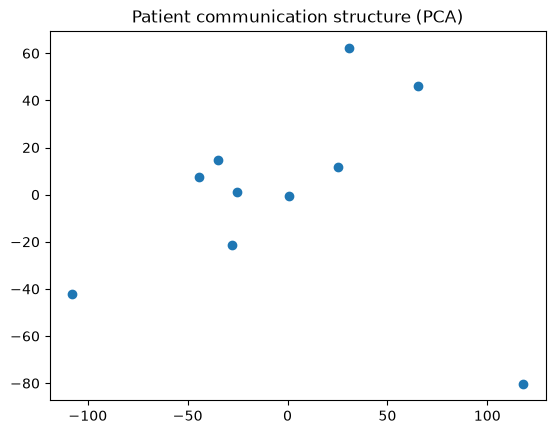

In [27]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("Patient communication structure (PCA)")
plt.show()

In [28]:
pca.explained_variance_ratio_

array([0.48893264, 0.20539583], dtype=float32)

In [29]:
outlier_idx = np.argmax(np.abs(X_pca).sum(axis=1))
outlier_idx

np.int64(3)

In [30]:
donors[:10][outlier_idx]

'wu_natgen_CID3838'

In [31]:
normal = np.delete(X_pca, outlier_idx, axis=0)

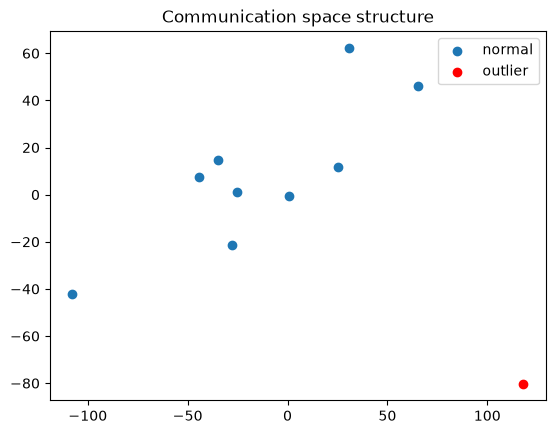

In [32]:
plt.scatter(normal[:,0], normal[:,1], label="normal")
plt.scatter(X_pca[outlier_idx,0], X_pca[outlier_idx,1], color="red", label="outlier")
plt.legend()
plt.title("Communication space structure")
plt.show()

In [33]:
feature_var = X_df.var().sort_values(ascending=False)
feature_var.head(20)

feature
VIM→CD44        658.791077
HMGB1→CXCR4     347.090179
CD99→CD81       247.174896
PKM→CD44        201.974823
HLA-A→APLP2     181.141556
TGFB1→ITGB1     148.156799
LGALS1→ITGB1    137.886688
TGFB1→CXCR4     131.693512
HLA-B→CD8A      130.612839
HLA-A→CD8A      126.322304
HLA-C→CD8A      113.110779
FN1→CD44        107.949509
MIF→TNFRSF14     99.175850
TIMP1→CD63       98.787140
HLA-E→CD8A       95.172920
APP→CD74         89.353668
HLA-B→CD3D       87.873154
LGALS1→PTPRC     81.237869
COL1A2→CD44      73.273514
HLA-B→CD8B       71.180695
dtype: float32

<Axes: title={'center': 'Most variable communication features'}, xlabel='feature'>

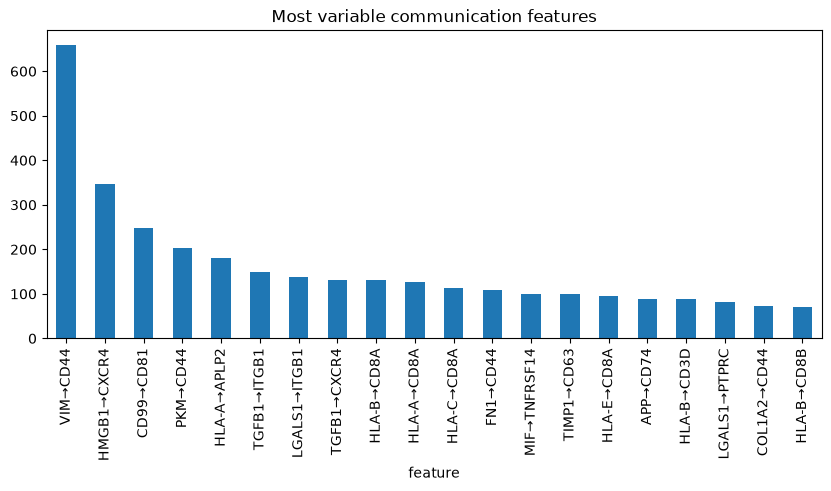

In [34]:
feature_var.head(20).plot(kind="bar", figsize=(10,4), title="Most variable communication features")

In [35]:
import numpy as np

corr = X_df.corr()
corr

feature,A2M→LRP1,ACTR2→ADRB2,ACTR2→LDLR,ADAM10→CD44,ADAM10→NOTCH1,ADAM10→TSPAN14,ADAM10→TSPAN5,ADAM12→ITGB1,ADAM15→ITGA5,ADAM15→ITGAV,...,VEGFA→CD44,VEGFA→ITGB1,VEGFB→NRP1,VEGFC→FLT1,VEGFC→ITGB1,VIM→CD44,VWF→ITGB1,VWF→SELP,VWF→SIRPA,YBX1→NOTCH1
feature,,,,,,,,,,,,,,,,,,,,,
A2M→LRP1,1.000000,-0.066623,0.620513,0.661711,-0.280764,-0.280764,-0.280764,0.301990,-0.154328,-0.131452,...,0.802511,0.730808,0.695135,-0.066623,0.329850,0.519610,0.088732,-0.328033,-0.227800,0.280840
ACTR2→ADRB2,-0.066623,1.000000,-0.012094,-0.460289,-0.111111,-0.111111,-0.111111,-0.030297,-0.368763,-0.213436,...,-0.164837,-0.020031,-0.111111,1.000000,-0.016793,-0.718090,-0.033061,0.235284,-0.149156,-0.190663
ACTR2→LDLR,0.620513,-0.012094,1.000000,0.781518,-0.153863,-0.153863,-0.153863,0.670762,-0.430215,-0.295558,...,0.711902,0.908903,0.964175,-0.012094,0.600930,0.449494,-0.045485,-0.251939,-0.206547,0.602159
ADAM10→CD44,0.661711,-0.460289,0.781518,1.000000,-0.101487,0.186306,-0.101487,0.552728,0.006051,0.110433,...,0.789207,0.765028,0.875740,-0.460289,0.674787,0.850225,0.288053,-0.458188,-0.142655,0.784246
ADAM10→NOTCH1,-0.280764,-0.111111,-0.153863,-0.101487,1.000000,-0.111111,1.000000,-0.227224,-0.368763,-0.213436,...,-0.164837,-0.206589,-0.111111,-0.111111,-0.289275,-0.147134,0.587935,0.712878,0.929195,0.046959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIM→CD44,0.519610,-0.718090,0.449494,0.850225,-0.147134,0.222402,-0.147134,0.308090,0.432843,0.350772,...,0.689171,0.555160,0.546417,-0.718090,0.335471,1.000000,0.156930,-0.464377,-0.238479,0.684592
VWF→ITGB1,0.088732,-0.033061,-0.045485,0.288053,0.587935,0.429302,0.587935,-0.057302,-0.001470,0.185456,...,0.083021,-0.094714,0.130762,-0.033061,0.279183,0.156930,1.000000,0.239025,0.533405,0.461852
VWF→SELP,-0.328033,0.235284,-0.251939,-0.458188,0.712878,-0.293411,0.712878,-0.334828,-0.269953,-0.330683,...,-0.435283,-0.356800,-0.293411,0.235284,-0.634234,-0.464377,0.239025,1.000000,0.582743,-0.195551


In [36]:
import numpy as np

corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

feature        feature      
IL16→CD9       ADAM10→NOTCH1    1.0
               ADAM10→TSPAN5    1.0
               CCL5→CCR5        1.0
FN1→ITGA2      PAM→FAP          1.0
SPP1→S1PR1     ACTR2→ADRB2      1.0
ADAM10→NOTCH1  IL16→CD9         1.0
ADAM10→TSPAN5  MFNG→NOTCH1      1.0
IL16→CD9       PAM→FAP          1.0
ADAM10→TSPAN5  FN1→ITGA2        1.0
IL16→CD9       PTHLH→RAMP2      1.0
SPP1→S1PR1     VEGFC→FLT1       1.0
FN1→ITGA2      ADAM10→TSPAN5    1.0
FN1→ITGA9      FN1→ITGA2        1.0
FN1→ITGA2      FN1→ITGA9        1.0
IL16→CD9       NID1→PTPRF       1.0
ADAM10→TSPAN5  IL16→CD9         1.0
VEGFC→FLT1     SPP1→S1PR1       1.0
MFNG→NOTCH1    ADAM10→TSPAN5    1.0
PTHLH→RAMP2    IL16→CD9         1.0
               CCL5→CCR5        1.0
dtype: float64

In [ ]:
"""
Not predefined pathways yet.

Instead:

data-driven modules of co-varying communication features
"""

In [37]:
import numpy as np
import pandas as pd

# correlation matrix already exists as corr
distance = 1 - corr.abs()
distance

feature,A2M→LRP1,ACTR2→ADRB2,ACTR2→LDLR,ADAM10→CD44,ADAM10→NOTCH1,ADAM10→TSPAN14,ADAM10→TSPAN5,ADAM12→ITGB1,ADAM15→ITGA5,ADAM15→ITGAV,...,VEGFA→CD44,VEGFA→ITGB1,VEGFB→NRP1,VEGFC→FLT1,VEGFC→ITGB1,VIM→CD44,VWF→ITGB1,VWF→SELP,VWF→SIRPA,YBX1→NOTCH1
feature,,,,,,,,,,,,,,,,,,,,,
A2M→LRP1,0.000000,0.933377,0.379487,0.338289,0.719236,0.719236,7.192362e-01,0.698010,0.845672,0.868548,...,0.197489,0.269192,0.304865,9.333766e-01,0.670150,0.480390,0.911268,0.671967,0.772200,0.719160
ACTR2→ADRB2,0.933377,0.000000,0.987906,0.539711,0.888889,0.888889,8.888889e-01,0.969703,0.631237,0.786564,...,0.835163,0.979969,0.888889,1.110223e-16,0.983207,0.281910,0.966939,0.764716,0.850844,0.809337
ACTR2→LDLR,0.379487,0.987906,0.000000,0.218482,0.846137,0.846137,8.461372e-01,0.329238,0.569785,0.704442,...,0.288098,0.091097,0.035825,9.879057e-01,0.399070,0.550506,0.954515,0.748061,0.793453,0.397841
ADAM10→CD44,0.338289,0.539711,0.218482,0.000000,0.898513,0.813694,8.985134e-01,0.447272,0.993949,0.889567,...,0.210793,0.234972,0.124260,5.397113e-01,0.325213,0.149775,0.711947,0.541812,0.857345,0.215754
ADAM10→NOTCH1,0.719236,0.888889,0.846137,0.898513,0.000000,0.888889,2.220446e-16,0.772776,0.631237,0.786564,...,0.835163,0.793411,0.888889,8.888889e-01,0.710725,0.852866,0.412065,0.287122,0.070805,0.953041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIM→CD44,0.480390,0.281910,0.550506,0.149775,0.852866,0.777598,8.528663e-01,0.691910,0.567157,0.649228,...,0.310829,0.444840,0.453583,2.819099e-01,0.664529,0.000000,0.843070,0.535623,0.761521,0.315408
VWF→ITGB1,0.911268,0.966939,0.954515,0.711947,0.412065,0.570698,4.120655e-01,0.942698,0.998530,0.814544,...,0.916979,0.905286,0.869238,9.669389e-01,0.720817,0.843070,0.000000,0.760975,0.466595,0.538148
VWF→SELP,0.671967,0.764716,0.748061,0.541812,0.287122,0.706589,2.871216e-01,0.665172,0.730047,0.669317,...,0.564717,0.643200,0.706589,7.647165e-01,0.365766,0.535623,0.760975,0.000000,0.417257,0.804449


In [40]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import numpy as np

# ensure valid distance matrix
distance = 1 - corr.abs()

# force numerical safety
distance = np.clip(distance, 0, 1)

dist_condensed = squareform(distance, checks=False)

Z = linkage(dist_condensed, method='average')

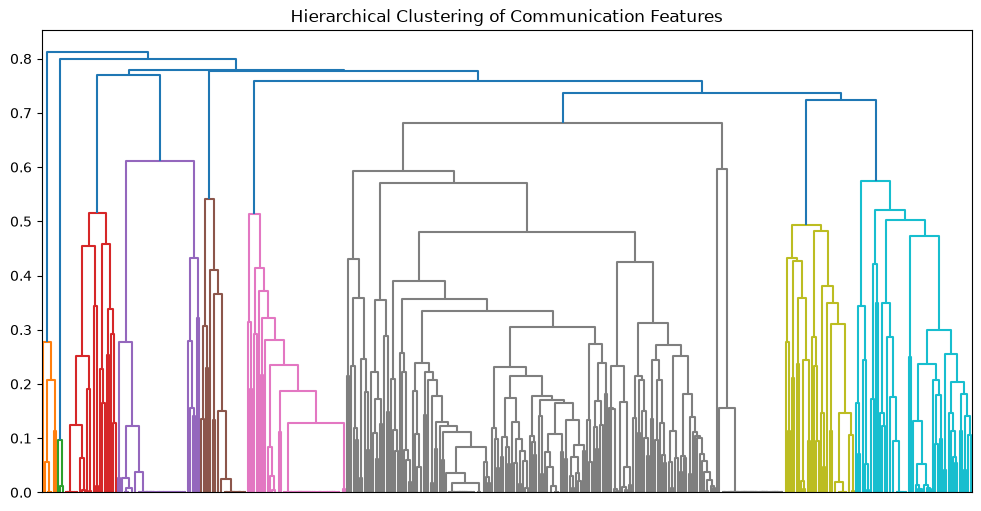

In [41]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=0.7
)

plt.title("Hierarchical Clustering of Communication Features")
plt.show()

In [42]:
from scipy.cluster.hierarchy import fcluster
import pandas as pd

# choose a moderate cutoff (we'll tune later if needed)
threshold = 0.7

clusters = fcluster(Z, t=threshold, criterion='distance')

cluster_df = pd.DataFrame({
    "feature": corr.index,
    "cluster": clusters
})

cluster_df.head()

,feature,cluster
0,A2M→LRP1,7
1,ACTR2→ADRB2,7
2,ACTR2→LDLR,7
3,ADAM10→CD44,7
4,ADAM10→NOTCH1,6


In [43]:
cluster_df["cluster"].nunique(), cluster_df["cluster"].value_counts().head(10)

(9,
 cluster
 7    199
 9     53
 6     45
 4     38
 8     32
 3     24
 5     21
 1      7
 2      3
 Name: count, dtype: int64)

In [44]:
top_clusters = cluster_df["cluster"].value_counts().index[:5]

for c in top_clusters:
    print("\nCluster:", c)
    display(cluster_df[cluster_df["cluster"] == c].head(15))


Cluster: 7


,feature,cluster
0,A2M→LRP1,7
1,ACTR2→ADRB2,7
2,ACTR2→LDLR,7
3,ADAM10→CD44,7
7,ADAM12→ITGB1,7
10,ADAM15→ITGB1,7
12,ADAM17→ITGB1,7
13,ADAM9→ITGB1,7
17,AGRN→ITGB1,7
23,ANXA1→DYSF,7



Cluster: 9


,feature,cluster
5,ADAM10→TSPAN14,9
8,ADAM15→ITGA5,9
9,ADAM15→ITGAV,9
31,APOE→SORL1,9
43,APP→TSPAN15,9
63,C1QB→C1QBP,9
65,C3→IFITM1,9
74,CALM1→PDE1A,9
76,CALM3→AQP1,9
78,CALR→ITGA3,9



Cluster: 6


,feature,cluster
4,ADAM10→NOTCH1,6
6,ADAM10→TSPAN5,6
37,APP→LRP6,6
39,APP→NOTCH2,6
42,APP→TSPAN12,6
81,CALR→SCARF1,6
83,CCL19→CCR7,6
89,CCL5→CCR5,6
92,CCN1→CAV1,6
106,CD52→SIGLEC10,6



Cluster: 4


,feature,cluster
18,ANGPT1→ITGB1,4
19,ANGPTL2→TIE1,4
20,ANGPTL4→CDH5,4
22,ANXA1→ADRA2A,4
33,APP→ADRA2A,4
41,APP→TNFRSF21,4
45,ARF1→PLD2,4
49,B2M→CD1B,4
53,B2M→KLRC1,4
54,B2M→KLRC2,4



Cluster: 8


,feature,cluster
15,ADM→RAMP2,8
16,ADM→RAMP3,8
24,ANXA1→FPR1,8
25,ANXA2→ROBO4,8
47,ARPC5→ADRB2,8
50,B2M→CD1C,8
56,BGN→LY96,8
60,BST2→LILRA4,8
68,CALM1→CRHR1,8
82,CCL14→ACKR1,8


In [48]:
program_scores = {}

for cluster_id in cluster_df["cluster"].unique():
    
    members = cluster_df[cluster_df["cluster"] == cluster_id]["feature"].values
    
    # ensure valid overlap with corr matrix
    valid_members = [m for m in members if m in corr.index]
    
    if len(valid_members) == 0:
        continue
    
    submatrix = corr.loc[valid_members, valid_members]
    
    program_scores[f"program_{cluster_id}"] = submatrix.values.mean()

In [50]:
program_scores

{'program_7': np.float64(0.3570158864703076),
 'program_6': np.float64(0.6757266188564931),
 'program_9': np.float64(0.565835008814303),
 'program_5': np.float64(0.5019643922829812),
 'program_2': np.float64(0.954601519879016),
 'program_8': np.float64(0.42249677862670054),
 'program_4': np.float64(0.7527473761415998),
 'program_3': np.float64(0.4957778821764167),
 'program_1': np.float64(0.8528756653963915)}

In [51]:
program_df = pd.DataFrame([program_scores])
program_df

,program_7,program_6,program_9,program_5,program_2,program_8,program_4,program_3,program_1
0,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876


In [52]:
X = program_df.copy()

X

,program_7,program_6,program_9,program_5,program_2,program_8,program_4,program_3,program_1
0,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876


In [53]:
print(X.shape)
print(X.columns)

(1, 9)
Index(['program_7', 'program_6', 'program_9', 'program_5', 'program_2',
       'program_8', 'program_4', 'program_3', 'program_1'],
      dtype='object')


In [54]:
adata.obs["donor_id"].value_counts().head(10)

donor_id
pal_Patient 0177    18812
pal_Patient 0176    17155
pal_Patient 0135    14709
TBB129              13340
TBB338              12893
pal_Patient 0178    12779
pal_Patient 0167    12213
pal_Patient 0337    11046
BC392_Tumor         10786
pal_Patient 0114     9851
Name: count, dtype: int64

In [55]:
adata.obs.groupby("donor_id")["cell_type"].nunique().head(10)

donor_id
BC258_Tumor    14
BC302_Tumor    18
BC389_Tumor    25
BC392_Tumor    29
BC393_Tumor    27
BC394_Tumor    17
BC397_Tumor    27
BC401_Tumor    12
BC419_Tumor    22
BC428_Tumor    15
Name: cell_type, dtype: int64

In [56]:
import pandas as pd
import numpy as np

donors = adata.obs["donor_id"].unique()

program_matrix = []

In [57]:
for donor in donors:
    
    ad = adata[adata.obs["donor_id"] == donor]
    
    donor_scores = {}
    
    for cluster_id in cluster_df["cluster"].unique():
        
        members = cluster_df[cluster_df["cluster"] == cluster_id]["feature"].values
        valid_members = [m for m in members if m in corr.index]
        
        if len(valid_members) == 0:
            continue
        
        sub = corr.loc[valid_members, valid_members]
        donor_scores[f"program_{cluster_id}"] = sub.values.mean()
    
    donor_scores["donor_id"] = donor
    program_matrix.append(donor_scores)

In [58]:
program_df = pd.DataFrame(program_matrix)

program_df.head()

,program_7,program_6,program_9,program_5,program_2,program_8,program_4,program_3,program_1,donor_id
0,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876,wu_natgen_CID3586
1,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876,wu_natgen_CID3921
2,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876,wu_natgen_CID45171
3,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876,wu_natgen_CID3838
4,0.357016,0.675727,0.565835,0.501964,0.954602,0.422497,0.752747,0.495778,0.852876,wu_natgen_CID4066


In [59]:
program_df.shape

(138, 10)

In [61]:
donor = program_df["donor_id"].iloc[0]

ad = adata[adata.obs["donor_id"] == donor].to_memory()

print(donor)
print(ad)
print(ad.X.shape)

wu_natgen_CID3586
AnnData object with n_obs × n_vars = 6176 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'
(6176, 37389)


In [62]:
ad.obs["cell_type"].value_counts()


cell_type
effector memory CD4-positive, alpha-beta T cell                             1310
naive T cell                                                                1269
effector memory CD8-positive, alpha-beta T cell                              875
malignant cell                                                               706
natural killer cell                                                          360
memory B cell                                                                322
T follicular helper cell                                                     313
CD4-positive, CD25-positive, CCR4-positive, alpha-beta regulatory T cell     310
fibroblast                                                                   186
macrophage                                                                   101
CD8-positive, alpha-beta regulatory T cell                                    89
endothelial cell of vascular tree                                             77
cycling T cell    

In [64]:
print(ad.var_names[:10])
print(ad.var["feature_name"][:10])

Index(['ENSG00000286448', 'ENSG00000225880', 'ENSG00000230368',
       'ENSG00000187634', 'ENSG00000188976', 'ENSG00000187961',
       'ENSG00000187583', 'ENSG00000187642', 'ENSG00000188290',
       'ENSG00000187608'],
      dtype='object')
ENSG00000286448    ENSG00000286448
ENSG00000225880          LINC00115
ENSG00000230368             FAM41C
ENSG00000187634             SAMD11
ENSG00000188976              NOC2L
ENSG00000187961             KLHL17
ENSG00000187583            PLEKHN1
ENSG00000187642              PERM1
ENSG00000188290               HES4
ENSG00000187608              ISG15
Name: feature_name, dtype: category
Categories (37361, object): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZZEF1', 'ZZZ3', 'hsa-mir-1253', 'hsa-mir-423']


In [65]:
ad.var_names = ad.var["feature_name"].astype(str)
ad.var_names_make_unique()

print("VIM" in ad.var_names)
print("CD44" in ad.var_names)

True
True
